# Example of the AiTLAS toolbox for generating feature embeddings using CACo

## Define the FAIREOSchema for dataset import

In [5]:
from marshmallow import fields, validate
from aitlas.base.schemas import BaseDatasetSchema

class FAIREOObjectDetectionCocoSchema(BaseDatasetSchema):
    """
    Schema for configuring an object detection dataset given in COCO format.
    """
    data_dir = fields.String(
        missing="/", description="Dataset path on disk", example="./data/DIOR/"
    )
    annotation_dir = fields.String(
        missing='/', description="json COCO files path on disk", example="./data/annotations/"
    )
    csv_file = fields.String(
        missing=None, description="CSV file on disk", example="./data/train.csv"
    )
    selection = fields.String(
        missing=None, description="Include all images or only images with labels", example="all"
    )

## Define the Functional Map of the World (fMoW) dataset class
Originally, this dataset contains both RGB (4 bands) and multispectral (8 bands) images. However, fMoW-rgb was implemented in our case. fMoW-rgb is in JPEG format, all multispectral imagery has been converted to RGB, and it is significantly smaller in size at ~200 GB.

In [6]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from aitlas.utils import image_loader
from aitlas.datasets.object_detection import BaseObjectDetectionDataset

'''
The dataset aims to inspire the development of machine learning models capable of predicting the functional 
purpose of buildings and land use from temporal sequences of satellite images and a rich set of metadata 
features. It contains more than 1 million images and 63 classes.
'''

class FMOWDataset(BaseObjectDetectionDataset):
    url = "https://github.com/fMoW/dataset"

    labels = ["false detection","airport","airport hangar","airpot terminal","amusement park","aquaculture","archeological site",
        "barn","border checkpoint","burial site","car dealership","construction site","crop field","dam","debris or rubble",
        "educational institution","electric substation","factory or powerplant","fire station","flooded road","fountain",
        "gas station","golf course","ground transportation station","helipad","hospital","impoverished settlement","interchange",
        "lake or pond","lighthouse","military facility","multi-unit residential","nuclear powerplant","office building",
        "oil or gas facility","park","parking lot or garage","place of worship","police station","port","prison","race track",
        "railway bridge","recreational facility","road bridge","runway","shipyard","shopping mall","single-unit residential",
        "smokestack","solar farm","space facility","stadium","storage tank","surface mine","swimming pool","toll booth",
        "tower","tunnel opening","waste disposal","water treatment facility","wind farm","zoo"]

    name = 'FMOW dataset'
    schema = FAIREOObjectDetectionCocoSchema

    def __init__(self, config):
        # now call the constructor to validate the schema
        super().__init__(config)

        # load the config
        self.data_dir = self.config.data_dir
        self.annotation_dir = self.config.annotation_dir

        # load the data
        self.labels, self.data, self.annotations, self.file_names = self.load_dataset(
            self.data_dir, self.annotation_dir
        )

    def __getitem__(self, index):
        """

        :param index: Index
        :type index: int
        :return: tuple where target is a dictionary where target is index of the target class
        :rtype: tuple of (image, target)

        """
        img_data = self.file_names[index]
        image = image_loader(os.path.join(self.data_dir, img_data)) / 255.0

        # annotation file
        name = img_data[: img_data.rfind('.jpg')]
        annotations_file_path = os.path.join(self.annotation_dir,name+'.json')
        annotations = json.load(open(annotations_file_path, "r"))
        
        boxes = []
        labels = []
        image_id = []
        filename = annotations['img_filename']

        for annotation in annotations["bounding_boxes"]:
            labels.append(self.labels.index(annotation["category"])) 
            image_id.append(filename)

            bbox = annotation["box"]

            if len(bbox) > 0:
                # bounding box
                xmin = bbox[0]
                xmax = bbox[0] + bbox[2]

                ymin = bbox[1]
                ymax = bbox[1] + bbox[3]

                boxes.append([xmin, ymin, xmax, ymax])

        # convert boxes into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # suppose all instances are not crowd
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        return self.apply_transformations(image, target)
        
    def load_dataset(self, data_dir=None, annotation_dir=None):
            labels = []
            annotations = []
            data = []
            file_names = []
            for json_file in os.listdir(annotation_dir):
                # Use os.path.join for robust path handling
                json_path = os.path.join(annotation_dir, json_file)
                coco = json.load(open(json_path, "r"))

                # read labels
                #labels = [None]  # add none for background
                labels += [y["category"] for y in sorted(coco["bounding_boxes"], key=lambda x: x["category"])]
                
                # create data
                filename = coco['img_filename']
                dataf = [
                    {
                        "file_name": coco["img_filename"],
                        "gsd": coco["gsd"],  # <-- GSD value loaded from JSON
                        **{
                            "annotations": [],
                            **{"file_name": coco["img_filename"]},
                        },
                    }
                ]
                data_inverted = {x["file_name"]: i for i, x in enumerate(dataf)}
                annotationsf = coco["bounding_boxes"]

                # create index and annotations
                for annotation in annotationsf:
                    bbox = []
                    for coor in annotation["box"]:
                        bbox.append(max(coor, 0))
                    annotation["bbox"] = bbox
                    key = data_inverted[filename]
                    dataf[key]["annotations"].append(annotation)
                    annotations.append(annotation)

                data.append(dataf)
                file_names.append(coco["img_filename"])

            labels = list(set(labels))

            return labels, data, annotations, file_names

    def data_distribution_table(self):
        df = pd.DataFrame(self.annotations)
        df = df.drop(['bbox','box','visible'], axis=1)        
        df_count = df.groupby("category").count()
        df_count = df_count.iloc[:, ::-1].reset_index()
        df_count.columns = ["Label", "Count"]
        
        return df_count

    def data_distribution_barchart(self):
        df_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.barplot(y="Label", x="Count", data=df_count, ax=ax)
        ax.set_title(
            "Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18
        )
        return fig

    def show_samples(self):
        df = pd.DataFrame(self.annotations)
        return df.head(20)

## Prepare the model

Prepare the CACo model

In [15]:
from aitlas.models import CACo

model_config = {
        "local_model_path": "tests/checkpoints/resnet18_caco_geo_100k_1000.pth",
        "backbone_name": "caco_resnet18",
        "pretrained": True
    }

'''model_config = {
        "local_model_path": "resnet50_caco_geo_100k_1000.pth",
        "backbone_name": "caco_resnet50",
        "pretrained": True
    }'''

model = CACo(model_config)

Loading weights from the provided local path: tests/checkpoints/resnet18_caco_geo_100k_1000.pth
Successfully loaded checkpoint: resnet18_caco_geo_100k_1000.pth


## Examples

### 1. RGB image examples

Load an example dataset with RGB images (4 bands)

In [8]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/fMoW/train_new_structure/images_rgb/",
    "annotation_dir": "/home/dragik/data/FAIR_EO/fMoW/train_new_structure/annotations_rgb/",
}
dataset = FMOWDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

Total number of patches: 360895


Plot images and show data distribution

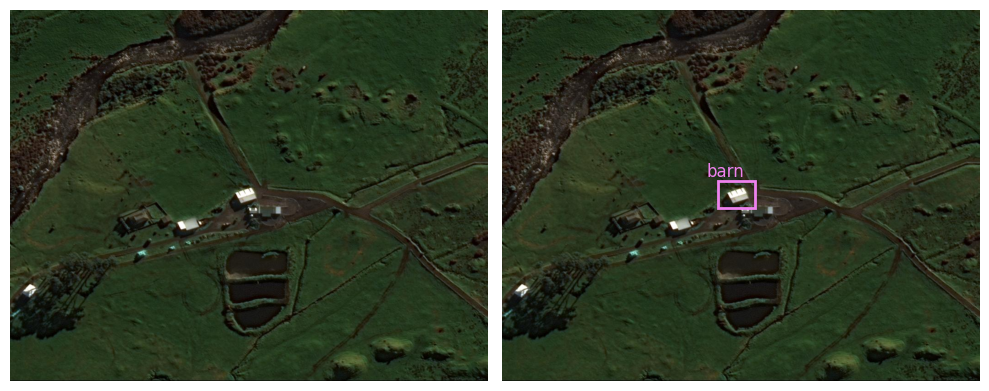

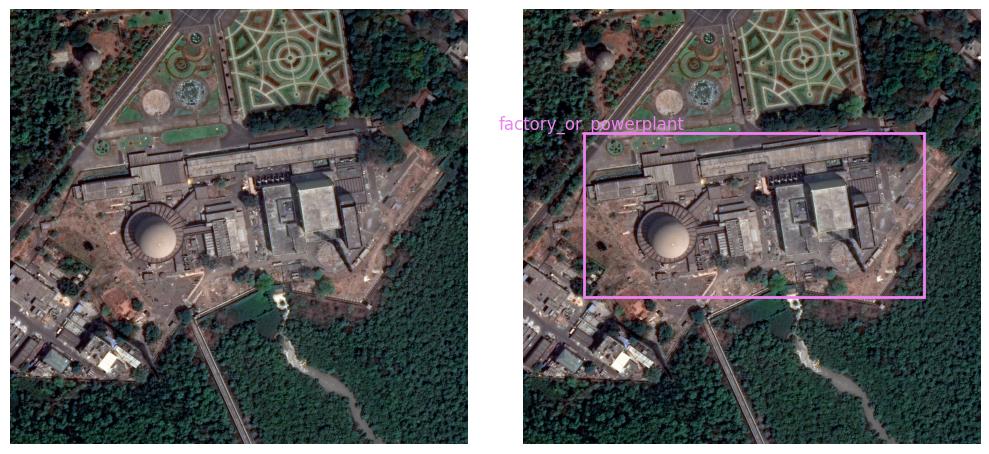

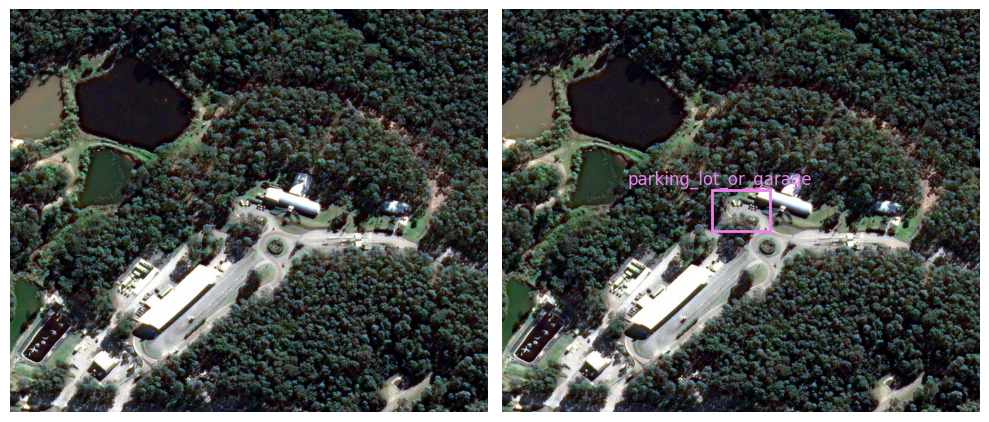

In [9]:
dataset.show_image(10);
dataset.show_image(50);
dataset.show_image(100);

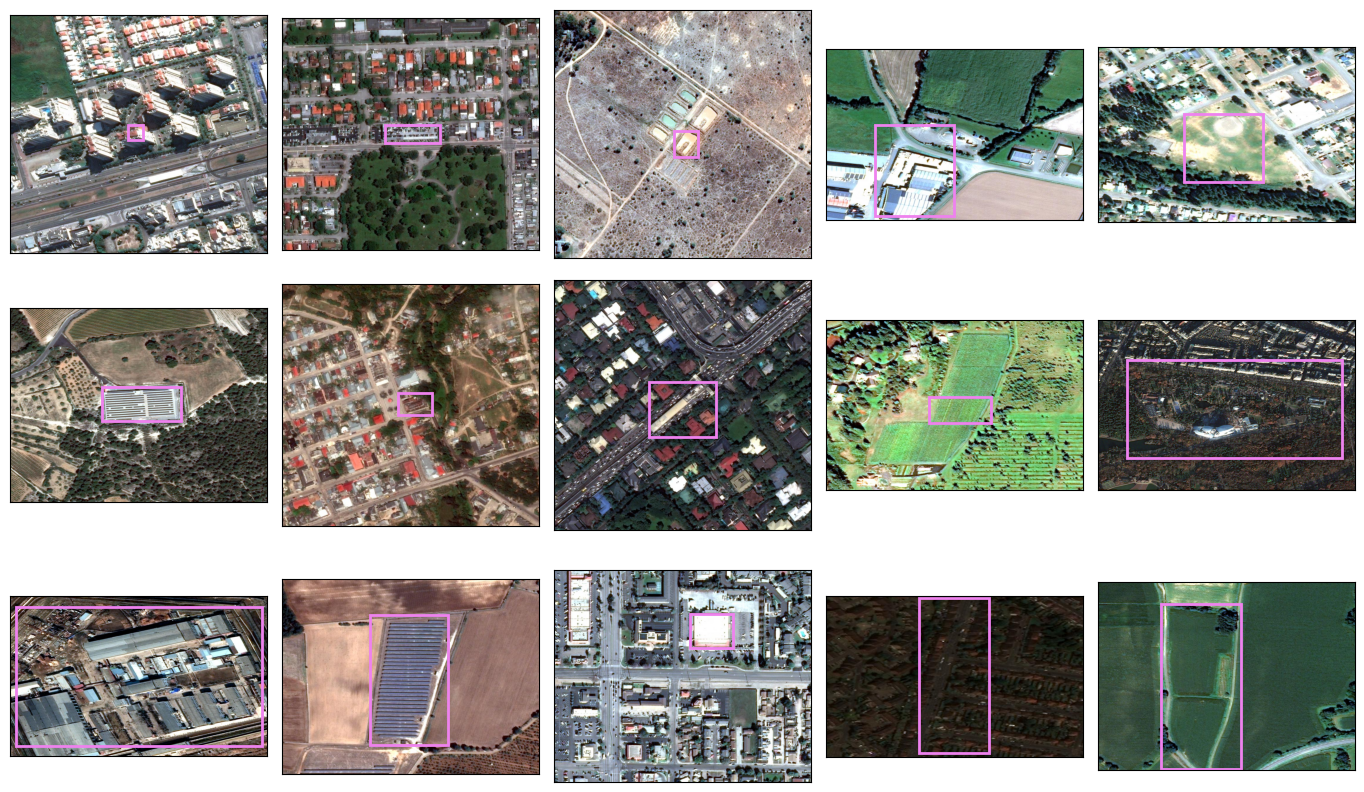

In [10]:
dataset.show_batch(15);

In [11]:
dataset.data_distribution_table()

,Label,Count
0,airport,1434
1,airport_hangar,4972
2,airport_terminal,4582
3,amusement_park,5888
4,aquaculture,1644
...,...,...
56,tunnel_opening,6330
57,waste_disposal,4301
58,water_treatment_facility,5517
59,wind_farm,5156


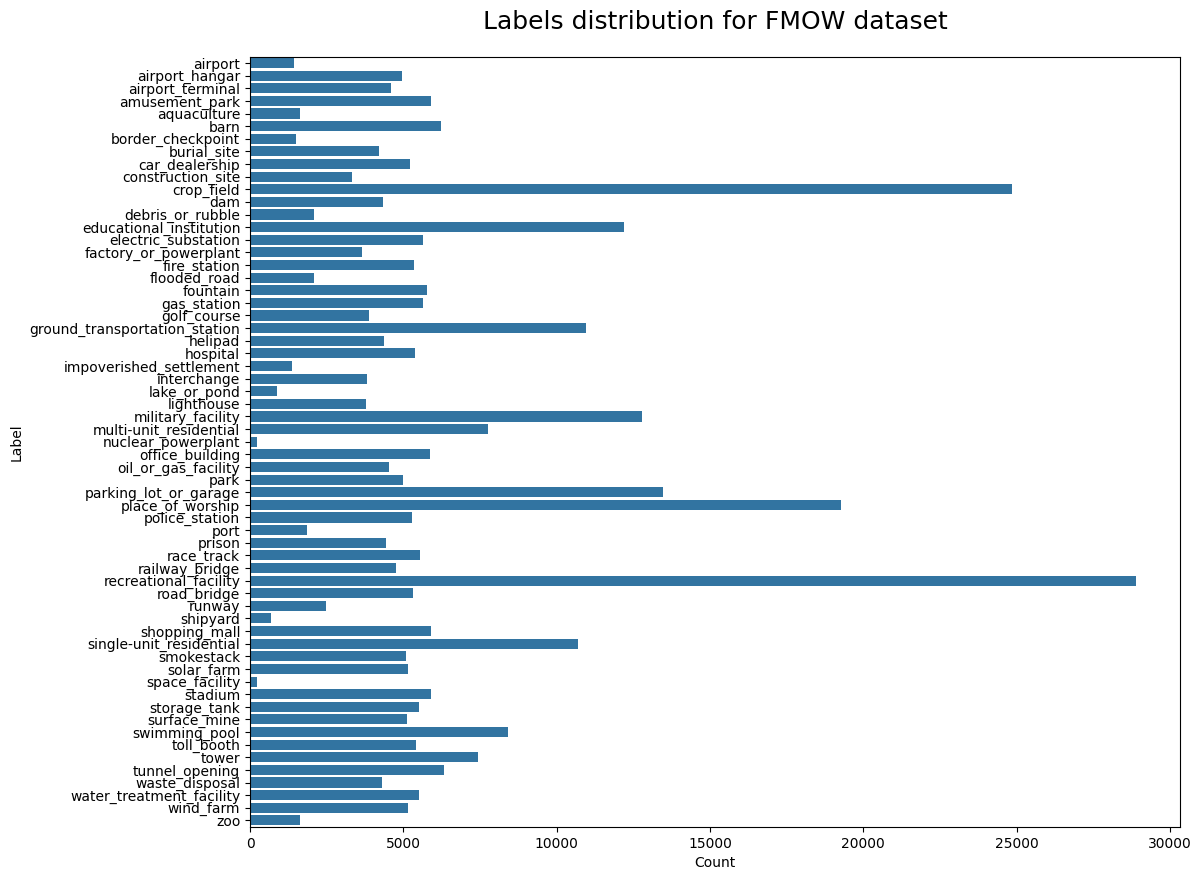

In [12]:
dataset.data_distribution_barchart();

#### 1.1 Example: Get feature embeddings for multiple RGB images as input

In [16]:
import os
import torch
from aitlas.utils import image_loader
from aitlas.transforms import ResizeCenterCropToTensor

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the number of images you want to load
N_batch = 4 

# Make sure we don't request more images than are in the dataset
if N_batch > len(dataset):
    raise ValueError(f"Requested {N_batch} images, but dataset only has {len(dataset)}.")

# This list will hold all processed image tensors
image_tensors = []

# Load and process N_batch images
for i in range(N_batch):  
    # Construct the full path to image
    path_to_image = os.path.join(dataset.data_dir, dataset.file_names[i]) 
    # Load the image
    image = image_loader(path_to_image)
    # Transform the image
    transform = ResizeCenterCropToTensor()
    image = transform(image) # Do not add a batch dimension this time
    # Add the processed tensor to the list of image tensors
    image_tensors.append(image)

# Combine the list of tensors into a single batch tensor
image_batch = torch.stack(image_tensors, dim=0) # The final shape will be (N_batch, C, H, W).

# Move the model, and images to the selected device
model = model.to(device)
image_batch = image_batch.to(device)

# Get feature embeddings using the CACo model
embeddings = model.forward_features(image_batch) # Use this to get the 512-dim embeddings (for resnet18) or 2048-dim embeddings (for resnet50)

# Print the input image shape and the embeddings shape
print(f"Input image shape: {image.shape}")
print(f"Input batch shape: {image_batch.shape}")
print(f"Embeddings shape: {embeddings.shape}")

Using device: cuda
Input image shape: torch.Size([3, 224, 224])
Input batch shape: torch.Size([4, 3, 224, 224])
Embeddings shape: torch.Size([4, 512])


In [ ]:
print(model)
print(model.backbone)

CACo(
  (model): Module()
  (backbone): MoCoV2CACoModule(
    (encoder_q): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn